# Setup of Case Study

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [6]:
# DB bağlantısı
DB_PATH = "papcorns.sqlite"

def query(sql: str, params=()) -> pd.DataFrame:
    """Run a SQL query against papcorns.sqlite and return a DataFrame."""
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn, params=params)

# Tablolara hızlı bakış
print("=== users ===")
display(query("SELECT * FROM users LIMIT 5"))
print("=== user_events ===")
display(query("SELECT * FROM user_events LIMIT 5"))
print("\nEvent types:", query("SELECT DISTINCT event_name FROM user_events")["event_name"].tolist())

=== users ===


,id,created_at,attribution_source,country,name
0,1,2024-05-07T00:00:00,instagram,US,Eve Brown
1,2,2024-10-12T00:00:00,instagram,NL,Frank Moore
2,3,2024-10-15T00:00:00,tiktok,TR,Ivy Anderson
3,4,2024-08-28T00:00:00,tiktok,TR,Alice Brown
4,5,2024-04-03T00:00:00,organic,NL,Bob Moore


=== user_events ===


,id,created_at,user_id,event_name,amount_usd
0,1,2024-05-07T00:00:00,1,app_install,None
1,2,2024-05-12T00:00:00,1,trial_started,None
2,3,2024-05-24T00:00:00,1,trial_cancelled,None
3,4,2024-10-12T00:00:00,2,app_install,None
4,5,2024-10-13T00:00:00,2,trial_started,None



Event types: ['app_install', 'trial_started', 'trial_cancelled', 'subscription_started', 'subscription_renewed', 'subscription_cancelled']


## Task 1 — Total Subscription Revenue by Country

**Approach:** Subscription revenue = `subscription_started` + `subscription_renewed` events.  
Trial events excluded as they carry no monetary value.

,country,total_revenue_usd,paying_users
0,US,4035.96,161
1,NL,3335.29,149
2,TR,2275.44,171


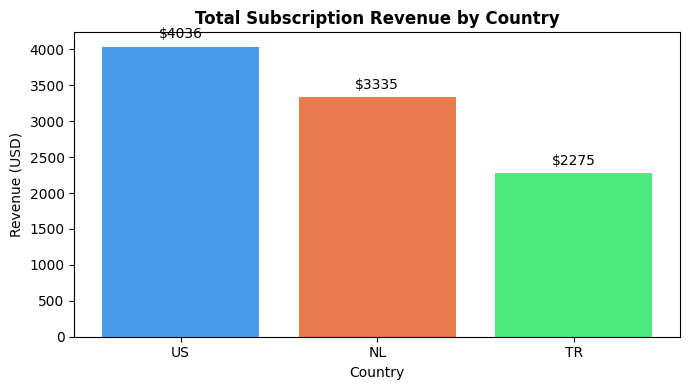

Insight: US leads with $4,035.96 in subscription revenue.


In [8]:
sql_task1 = """
SELECT
    u.country,
    ROUND(SUM(e.amount_usd), 2)  AS total_revenue_usd,
    COUNT(DISTINCT e.user_id)    AS paying_users
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE e.event_name IN ('subscription_started', 'subscription_renewed')
GROUP BY u.country
ORDER BY total_revenue_usd DESC
"""

df1 = query(sql_task1)
display(df1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df1["country"], df1["total_revenue_usd"],
              color=["#4C9BE8", "#E87B4C", "#4CE87B"])
ax.bar_label(bars, fmt="$%.0f", padding=4)
ax.set_title("Total Subscription Revenue by Country", fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (USD)")
ax.set_xlabel("Country")
plt.tight_layout()
plt.show()

print(f"Insight: {df1.iloc[0]['country']} leads with ${df1.iloc[0]['total_revenue_usd']:,.2f} in subscription revenue.")